# Tutorial 11F: Complete Case Study - Brazilian Manufacturing Firms (Solution)

**Module**: Stochastic Frontier Analysis | **Difficulty**: Advanced | **Duration**: 5-6 hours

**Prerequisites**: All previous tutorials (01-05)

## Learning Objectives

1. Apply a complete SFA workflow from data exploration to reporting
2. Integrate concepts from all previous tutorials
3. Conduct rigorous model selection and validation
4. Analyze efficiency and productivity patterns
5. Identify policy-relevant determinants of inefficiency
6. Produce publication-quality outputs (tables, figures, reports)

## 1. Setup and Data Loading

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
from pathlib import Path

import statsmodels.api as sm
from scipy import stats

from panelbox.datasets import load_dataset
from panelbox.frontier import FourComponentSFA, StochasticFrontier
from panelbox.frontier.tests import inefficiency_presence_test, lr_test

np.random.seed(42)
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

BASE_DIR = Path("..")
FIGURES_DIR = BASE_DIR / "outputs" / "figures" / "06_case_study"
TABLES_DIR_LATEX = BASE_DIR / "outputs" / "tables" / "latex"
TABLES_DIR_HTML = BASE_DIR / "outputs" / "tables" / "html"
REPORTS_DIR = BASE_DIR / "outputs" / "reports" / "efficiency_reports"

for d in [FIGURES_DIR, TABLES_DIR_LATEX, TABLES_DIR_HTML, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete!")

In [ ]:
data = load_dataset("brazilian_firms", category="frontier")

print("=" * 80)
print("BRAZILIAN MANUFACTURING FIRMS: EFFICIENCY AND PRODUCTIVITY ANALYSIS")
print("=" * 80)
print(f"\nDataset shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
display(data.head())

## 2. Phase 1: Data Exploration and Preparation

### 2.1 Panel Structure

In [3]:
print("=" * 70)
print("1. DATASET STRUCTURE")
print("=" * 70)
print(f"  Total observations: {len(data)}")
print(f"  Number of firms:    {data['firm_id'].nunique()}")
print(f"  Time periods:       {data['year'].min()} - {data['year'].max()}")
print(f"  Number of years:    {data['year'].nunique()}")

balance_check = data.groupby("firm_id").size()
print(f"  Balanced panel:     {balance_check.nunique() == 1}")
print(f"  Obs per firm:       min={balance_check.min()}, max={balance_check.max()}")

print("\n2. SECTORAL DISTRIBUTION")
print(data["sector"].value_counts().to_string())

print("\n3. REGIONAL DISTRIBUTION")
region_map = {"SE": "Southeast", "S": "South", "NE": "Northeast", "N": "North", "CO": "Center-West"}
print(data["region"].map(region_map).value_counts().to_string())

1. DATASET STRUCTURE
  Total observations: 5000
  Number of firms:    500
  Time periods:       2010 - 2019
  Number of years:    10
  Balanced panel:     True
  Obs per firm:       min=10, max=10

2. SECTORAL DISTRIBUTION
sector
food           1120
machinery       690
metals          640
electronics     630
textiles        570
chemicals       530
automotive      440
pharma          380

3. REGIONAL DISTRIBUTION
region
Southeast      1910
South          1070
Northeast       950
Center-West     650
North           420


### 2.2 Summary Statistics

In [4]:
print("=" * 70)
print("4. SUMMARY STATISTICS")
print("=" * 70)
vars_summary = ["log_output", "log_labor", "log_capital", "log_materials", "firm_age", "r_and_d"]
display(data[vars_summary].describe().round(4))

print("\n5. BINARY VARIABLES")
print(f"  Exporters:     {data['exporter'].sum()} ({100 * data['exporter'].mean():.1f}%)")
print(f"  Foreign-owned: {data['foreign_owned'].sum()} ({100 * data['foreign_owned'].mean():.1f}%)")

4. SUMMARY STATISTICS


,log_output,log_labor,log_capital,log_materials,firm_age,r_and_d
count,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000
mean,1.9874,4.5915,7.0874,7.5750,29.9788,1.9250
std,1.1268,1.5114,2.0355,1.8005,14.4810,2.0815
min,-1.4212,-0.5724,-0.7908,1.6261,1.0000,0.0000
25%,1.1856,3.5520,5.7467,6.3699,19.6000,0.5475
50%,1.9393,4.5631,7.0747,7.5672,29.9000,1.2800
75%,2.7272,5.6181,8.4482,8.7807,39.3000,2.7300
max,6.7479,10.7927,14.4737,14.7284,76.9000,14.2600



5. BINARY VARIABLES
  Exporters:     1480 (29.6%)
  Foreign-owned: 780 (15.6%)


### 2.3 Data Quality

In [5]:
print("=" * 70)
print("6. DATA QUALITY CHECKS")
print("=" * 70)

missing = data.isnull().sum()
if missing.sum() == 0:
    print("  Missing values: None detected")
else:
    print(missing[missing > 0])

print("\n  Outlier detection (3x IQR rule):")
for var in ["log_output", "log_labor", "log_capital", "log_materials"]:
    Q1 = data[var].quantile(0.25)
    Q3 = data[var].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data[var] < (Q1 - 3 * IQR)) | (data[var] > (Q3 + 3 * IQR))).sum()
    print(f"    {var:<18}: {n_outliers} outliers")

6. DATA QUALITY CHECKS
  Missing values: None detected

  Outlier detection (3x IQR rule):
    log_output        : 0 outliers
    log_labor         : 0 outliers
    log_capital       : 0 outliers
    log_materials     : 0 outliers


### 2.4 Exploratory Visualizations

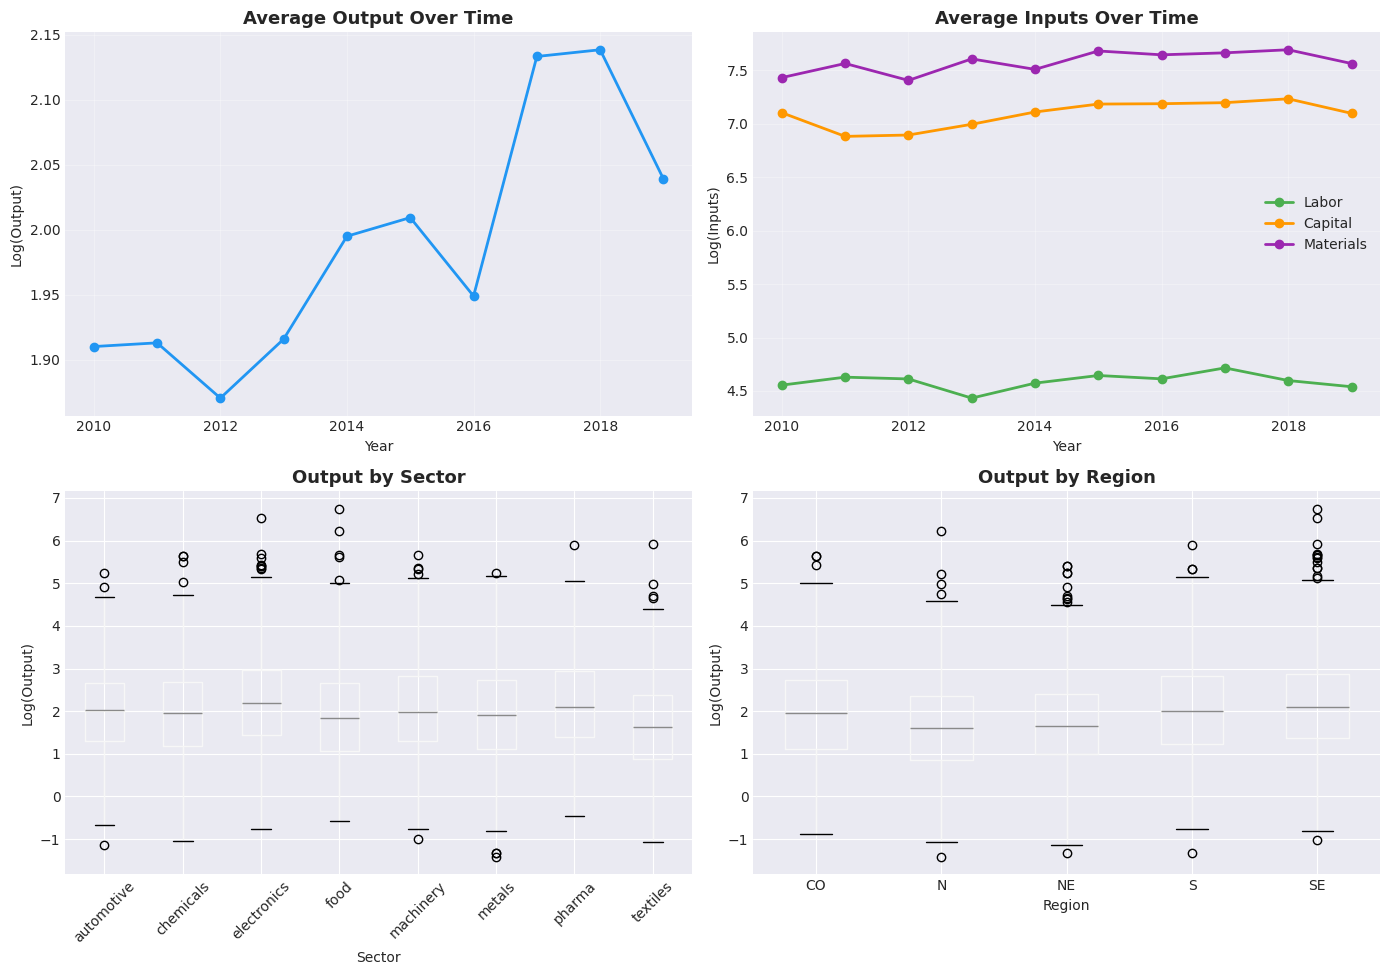

Figure saved: ../outputs/figures/06_case_study/exploratory_analysis.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

avg_output = data.groupby("year")["log_output"].mean()
axes[0, 0].plot(avg_output.index, avg_output.values, marker="o", linewidth=2, color="#2196F3")
axes[0, 0].set_title("Average Output Over Time", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Log(Output)")
axes[0, 0].grid(True, alpha=0.3)

colors_in = ["#4CAF50", "#FF9800", "#9C27B0"]
for (var, label), c in zip(
    [("log_labor", "Labor"), ("log_capital", "Capital"), ("log_materials", "Materials")], colors_in
):
    avg = data.groupby("year")[var].mean()
    axes[0, 1].plot(avg.index, avg.values, marker="o", label=label, linewidth=2, color=c)
axes[0, 1].set_title("Average Inputs Over Time", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Log(Inputs)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

data.boxplot(column="log_output", by="sector", ax=axes[1, 0])
axes[1, 0].set_title("Output by Sector", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Sector")
axes[1, 0].set_ylabel("Log(Output)")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].get_figure().suptitle("")

data.boxplot(column="log_output", by="region", ax=axes[1, 1])
axes[1, 1].set_title("Output by Region", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Region")
axes[1, 1].set_ylabel("Log(Output)")
axes[1, 1].get_figure().suptitle("")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "exploratory_analysis.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved:", FIGURES_DIR / "exploratory_analysis.png")

## 3. Phase 2: Model Specification and Selection

### 3.1 Test for Presence of Inefficiency

In [7]:
print("=" * 70)
print("STEP 1: TEST FOR PRESENCE OF INEFFICIENCY")
print("=" * 70)

X_ols = sm.add_constant(data[["log_labor", "log_capital", "log_materials"]])
y_ols = data["log_output"]
ols_result = sm.OLS(y_ols, X_ols).fit()
print(f"  OLS Log-Lik: {ols_result.llf:.4f}")

sfa_baseline = StochasticFrontier(
    data=data,
    depvar="log_output",
    exog=["log_labor", "log_capital", "log_materials"],
    entity="firm_id",
    time="year",
    frontier="production",
    dist="half_normal",
    model_type="pooled",
)
result_baseline = sfa_baseline.fit(method="mle", optimizer="L-BFGS-B")
print(f"  SFA Log-Lik: {result_baseline.loglik:.4f}")

try:
    ineff_test = inefficiency_presence_test(
        loglik_sfa=result_baseline.loglik,
        loglik_ols=ols_result.llf,
        residuals_ols=ols_result.resid.values,
        frontier_type="production",
        distribution="half_normal",
    )
    print(f"  LR Statistic: {ineff_test['lr_statistic']:.4f}")
    print(f"  P-value:      {ineff_test['pvalue']:.6f}")
    print(f"  Conclusion:   {ineff_test['conclusion']}")
except Exception:
    lr_stat = 2 * (result_baseline.loglik - ols_result.llf)
    pvalue = 0.5 * stats.chi2.sf(max(lr_stat, 0), 1)
    print(f"  LR stat: {lr_stat:.4f}, P-value: {pvalue:.6f}")

STEP 1: TEST FOR PRESENCE OF INEFFICIENCY
  OLS Log-Lik: -3721.4878
  SFA Log-Lik: -3720.0945
  LR Statistic: 2.7865
  P-value:      0.047530
  Conclusion:   SFA needed


### 3.2 Compare Distributions

In [8]:
print("=" * 70)
print("STEP 2: SELECT DISTRIBUTION")
print("=" * 70)

distributions = ["half_normal", "exponential", "truncated_normal"]
dist_labels = ["Half-Normal", "Exponential", "Truncated Normal"]
dist_results = {}

for dist, label in zip(distributions, dist_labels):
    try:
        model = StochasticFrontier(
            data=data,
            depvar="log_output",
            exog=["log_labor", "log_capital", "log_materials"],
            entity="firm_id",
            time="year",
            frontier="production",
            dist=dist,
            model_type="pooled",
        )
        res = model.fit(method="mle", optimizer="L-BFGS-B")
        dist_results[dist] = res
        print(f"  {label}: LogL={res.loglik:.4f} AIC={res.aic:.4f} BIC={res.bic:.4f}")
    except Exception as e:
        print(f"  {label}: ERROR - {e}")

comparison_data = []
for dist, label in zip(distributions, dist_labels):
    if dist in dist_results:
        r = dist_results[dist]
        eff = r.efficiency(estimator="bc", ci_level=0.95)
        comparison_data.append(
            {
                "Distribution": label,
                "Log-Lik": r.loglik,
                "AIC": r.aic,
                "BIC": r.bic,
                "sigma_u": r.sigma_u,
                "sigma_v": r.sigma_v,
                "gamma": r.gamma,
                "Mean TE": eff["efficiency"].mean(),
            }
        )

dist_comparison = pd.DataFrame(comparison_data)
display(dist_comparison.round(4))

best_dist = dist_comparison.loc[dist_comparison["BIC"].idxmin(), "Distribution"]
best_dist_key = distributions[dist_labels.index(best_dist)]
print(f"\nBest distribution by BIC: {best_dist}")

STEP 2: SELECT DISTRIBUTION
  Half-Normal: LogL=-3720.0945 AIC=7452.1890 BIC=7491.2922
  Exponential: LogL=85053.1896 AIC=-170094.3793 BIC=-170055.2761
  Truncated Normal: LogL=-3720.0939 AIC=7454.1878 BIC=7499.8082


,Distribution,Log-Lik,AIC,BIC,sigma_u,sigma_v,gamma,Mean TE
0,Half-Normal,-3720.0945,7452.1890,7491.2922,0.3173,0.4721,0.3112,0.7898
1,Exponential,85053.1896,-170094.3793,-170055.2761,0.1516,0.4864,0.0886,0.7216
2,Truncated Normal,-3720.0939,7454.1878,7499.8082,0.3173,0.4721,0.3112,0.7898



Best distribution by BIC: Exponential


### 3.3 Select Panel Specification

In [9]:
print("=" * 70)
print("STEP 3: SELECT PANEL MODEL")
print("=" * 70)

panel_specs = {"Pooled": "pooled", "Pitt-Lee": "pitt_lee", "BC92": "bc92"}
panel_results = {}

for name, mtype in panel_specs.items():
    try:
        model = StochasticFrontier(
            data=data,
            depvar="log_output",
            exog=["log_labor", "log_capital", "log_materials"],
            entity="firm_id",
            time="year",
            frontier="production",
            dist=best_dist_key,
            model_type=mtype,
        )
        res = model.fit(method="mle", optimizer="L-BFGS-B")
        panel_results[name] = res
        print(f"  {name}: LogL={res.loglik:.4f} AIC={res.aic:.4f} BIC={res.bic:.4f}")
    except Exception as e:
        print(f"  {name}: ERROR - {e}")

panel_comp_data = []
for name in panel_specs:
    if name in panel_results:
        r = panel_results[name]
        panel_comp_data.append(
            {
                "Model": name,
                "Log-Lik": r.loglik,
                "AIC": r.aic,
                "BIC": r.bic,
                "N Params": r.nparams,
                "sigma_u": r.sigma_u,
                "sigma_v": r.sigma_v,
                "gamma": r.gamma,
            }
        )

panel_comp_df = pd.DataFrame(panel_comp_data)
display(panel_comp_df.round(4))

# LR tests
if "Pooled" in panel_results and "Pitt-Lee" in panel_results:
    lr_pp = lr_test(
        panel_results["Pooled"].loglik,
        panel_results["Pitt-Lee"].loglik,
        panel_results["Pitt-Lee"].nparams - panel_results["Pooled"].nparams,
    )
    print(f"\nLR Test (Pooled vs Pitt-Lee): stat={lr_pp['statistic']:.4f} p={lr_pp['pvalue']:.6f}")

best_panel = panel_comp_df.loc[panel_comp_df["BIC"].idxmin(), "Model"]
print(f"\nBest panel model by BIC: {best_panel}")
best_model = panel_results[best_panel]

STEP 3: SELECT PANEL MODEL


  Pooled: LogL=85053.1896 AIC=-170094.3793 BIC=-170055.2761


  Pitt-Lee: LogL=85053.1896 AIC=-170094.3793 BIC=-170055.2761


  BC92: LogL=-3716.4415 AIC=7446.8831 BIC=7492.5034


,Model,Log-Lik,AIC,BIC,N Params,sigma_u,sigma_v,gamma
0,Pooled,85053.1896,-170094.3793,-170055.2761,6,0.1516,0.4864,0.0886
1,Pitt-Lee,85053.1896,-170094.3793,-170055.2761,6,0.1516,0.4864,0.0886
2,BC92,-3716.4415,7446.8831,7492.5034,7,0.2689,0.4749,0.2428



LR Test (Pooled vs Pitt-Lee): stat=0.0000 p=nan

Best panel model by BIC: Pooled


### 3.4 Test Returns to Scale

In [10]:
print("=" * 70)
print("STEP 4: RETURNS TO SCALE")
print("=" * 70)

try:
    rts_result = best_model.returns_to_scale_test(
        input_vars=["log_labor", "log_capital", "log_materials"]
    )
    print(f"  RTS: {rts_result['rts']:.4f} (SE={rts_result['rts_se']:.4f})")
    print(f"  95% CI: [{rts_result['ci'][0]:.4f}, {rts_result['ci'][1]:.4f}]")
    print(f"  P-value: {rts_result['pvalue']:.4f}")
    print(f"  Conclusion: {rts_result['conclusion']}")
    rts_conclusion = rts_result["conclusion"]
except Exception as e:
    print(f"  RTS test: {e}")
    rts_val = sum(
        best_model.params.get(v, 0) for v in ["log_labor", "log_capital", "log_materials"]
    )
    rts_conclusion = "IRS" if rts_val > 1.05 else ("DRS" if rts_val < 0.95 else "CRS")
    print(f"  Manual RTS: {rts_val:.4f} -> {rts_conclusion}")

STEP 4: RETURNS TO SCALE
  RTS: 2.6584 (SE=7.2809)
  95% CI: [-11.6120, 16.9288]
  P-value: 0.8198
  Conclusion: CRS


In [11]:
print("\n" + "=" * 70)
print("FINAL MODEL SPECIFICATION")
print("=" * 70)
print(f"  Distribution:   {best_dist}")
print(f"  Panel model:    {best_panel}")
print(f"  Returns to scale: {rts_conclusion}")
print(f"  Log-likelihood: {best_model.loglik:.2f}")
print(f"  AIC:            {best_model.aic:.2f}")
print(f"  BIC:            {best_model.bic:.2f}")

print("\n" + best_model.summary())


FINAL MODEL SPECIFICATION
  Distribution:   Exponential
  Panel model:    Pooled
  Returns to scale: CRS
  Log-likelihood: 85053.19
  AIC:            -170094.38
  BIC:            -170055.28

                     Stochastic Frontier Analysis Results                     
Model:                  pooled
Frontier:               production
Distribution:           exponential
No. Observations:       5000
No. Entities:           500
No. Time Periods:       10
Balanced Panel:         True
Log-Likelihood:         85053.1896
AIC:                    -170094.3793
BIC:                    -170055.2761
Converged:              True
------------------------------------------------------------------------------
Variance Components:
  σ_v (noise):          0.486385
  σ_u (inefficiency):   0.151631
  σ (composite):        0.509473
  λ = σ_u/σ_v:          0.311750
  γ = σ²_u/σ²:          0.088579
------------------------------------------------------------------------------
Variance Decomposition:
  γ (ine

## 4. Phase 3: Efficiency Analysis

### 4.1 Efficiency Scores

In [12]:
print("=" * 70)
print("PHASE 3: EFFICIENCY ANALYSIS")
print("=" * 70)

try:
    eff_df = best_model.efficiency(estimator="bc", ci_level=0.95, by_period=True)
except TypeError:
    eff_df = best_model.efficiency(estimator="bc", ci_level=0.95)

data_eff = data.copy()
if len(eff_df) == len(data):
    data_eff["te"] = eff_df["efficiency"].values
elif "entity" in eff_df.columns:
    data_eff = data_eff.merge(
        eff_df.rename(columns={"entity": "firm_id"})[["firm_id", "efficiency"]],
        on="firm_id",
        how="left",
    )
    data_eff = data_eff.rename(columns={"efficiency": "te"})

print("\n1. OVERALL EFFICIENCY STATISTICS")
print(data_eff["te"].describe().round(4))

PHASE 3: EFFICIENCY ANALYSIS

1. OVERALL EFFICIENCY STATISTICS
count    5000.0000
mean        0.7216
std         0.3641
min         0.0028
25%         0.3693
50%         1.0000
75%         1.0000
max         1.0000
Name: te, dtype: float64


### 4.2 Temporal, Sectoral, and Regional Patterns

In [13]:
print("\n2. EFFICIENCY EVOLUTION OVER TIME")
eff_by_year = data_eff.groupby("year")["te"].agg(["mean", "std", "min", "max"]).round(4)
display(eff_by_year)

years = eff_by_year.index.values
means = eff_by_year["mean"].values
slope, intercept, r_value, p_trend, _ = stats.linregress(years, means)
print(f"  Trend: slope={slope:.6f}, p={p_trend:.4f}")

print("\n3. EFFICIENCY BY SECTOR")
eff_by_sector = data_eff.groupby("sector")["te"].agg(["mean", "std", "count"]).round(4)
eff_by_sector = eff_by_sector.sort_values("mean", ascending=False)
display(eff_by_sector)

print("\n4. EFFICIENCY BY REGION")
region_map = {"SE": "Southeast", "S": "South", "NE": "Northeast", "N": "North", "CO": "Center-West"}
data_eff["region_name"] = data_eff["region"].map(region_map)
eff_by_region = data_eff.groupby("region_name")["te"].agg(["mean", "std", "count"]).round(4)
eff_by_region = eff_by_region.sort_values("mean", ascending=False)
display(eff_by_region)

print("\n5. TOP 10 MOST EFFICIENT FIRMS")
firm_avg = data_eff.groupby("firm_id")["te"].mean().sort_values(ascending=False)
display(firm_avg.head(10).round(4))

print("\n6. BOTTOM 10 LEAST EFFICIENT FIRMS")
display(firm_avg.tail(10).round(4))


2. EFFICIENCY EVOLUTION OVER TIME


,mean,std,min,max
year,,,,
2010,0.7380,0.3613,0.0119,1.0
2011,0.7296,0.3550,0.0028,1.0
2012,0.7392,0.3611,0.0064,1.0
2013,0.7375,0.3580,0.0087,1.0
2014,0.7257,0.3609,0.0038,1.0
2015,0.6904,0.3781,0.0035,1.0
2016,0.6846,0.3771,0.0060,1.0
2017,0.7072,0.3651,0.0052,1.0
2018,0.7182,0.3684,0.0046,1.0


  Trend: slope=-0.002193, p=0.3798

3. EFFICIENCY BY SECTOR


,mean,std,count
sector,,,
pharma,0.7582,0.3535,380
electronics,0.7536,0.3452,630
machinery,0.7489,0.3480,690
chemicals,0.7276,0.3642,530
food,0.7086,0.3725,1120
metals,0.7052,0.3686,640
automotive,0.6930,0.3730,440
textiles,0.6898,0.3762,570



4. EFFICIENCY BY REGION


,mean,std,count
region_name,,,
Southeast,0.7557,0.3496,1910
South,0.7325,0.3627,1070
Center-West,0.7036,0.3680,650
Northeast,0.6836,0.3762,950
North,0.6529,0.3800,420



5. TOP 10 MOST EFFICIENT FIRMS


firm_id
76     1.0000
101    1.0000
159    1.0000
433    1.0000
245    1.0000
200    1.0000
210    0.9964
240    0.9892
447    0.9709
424    0.9692
Name: te, dtype: float64


6. BOTTOM 10 LEAST EFFICIENT FIRMS


firm_id
38     0.4454
395    0.4450
298    0.4423
313    0.4215
455    0.4197
372    0.4114
181    0.3859
436    0.3528
305    0.3277
125    0.3031
Name: te, dtype: float64

### 4.3 Efficiency Visualizations

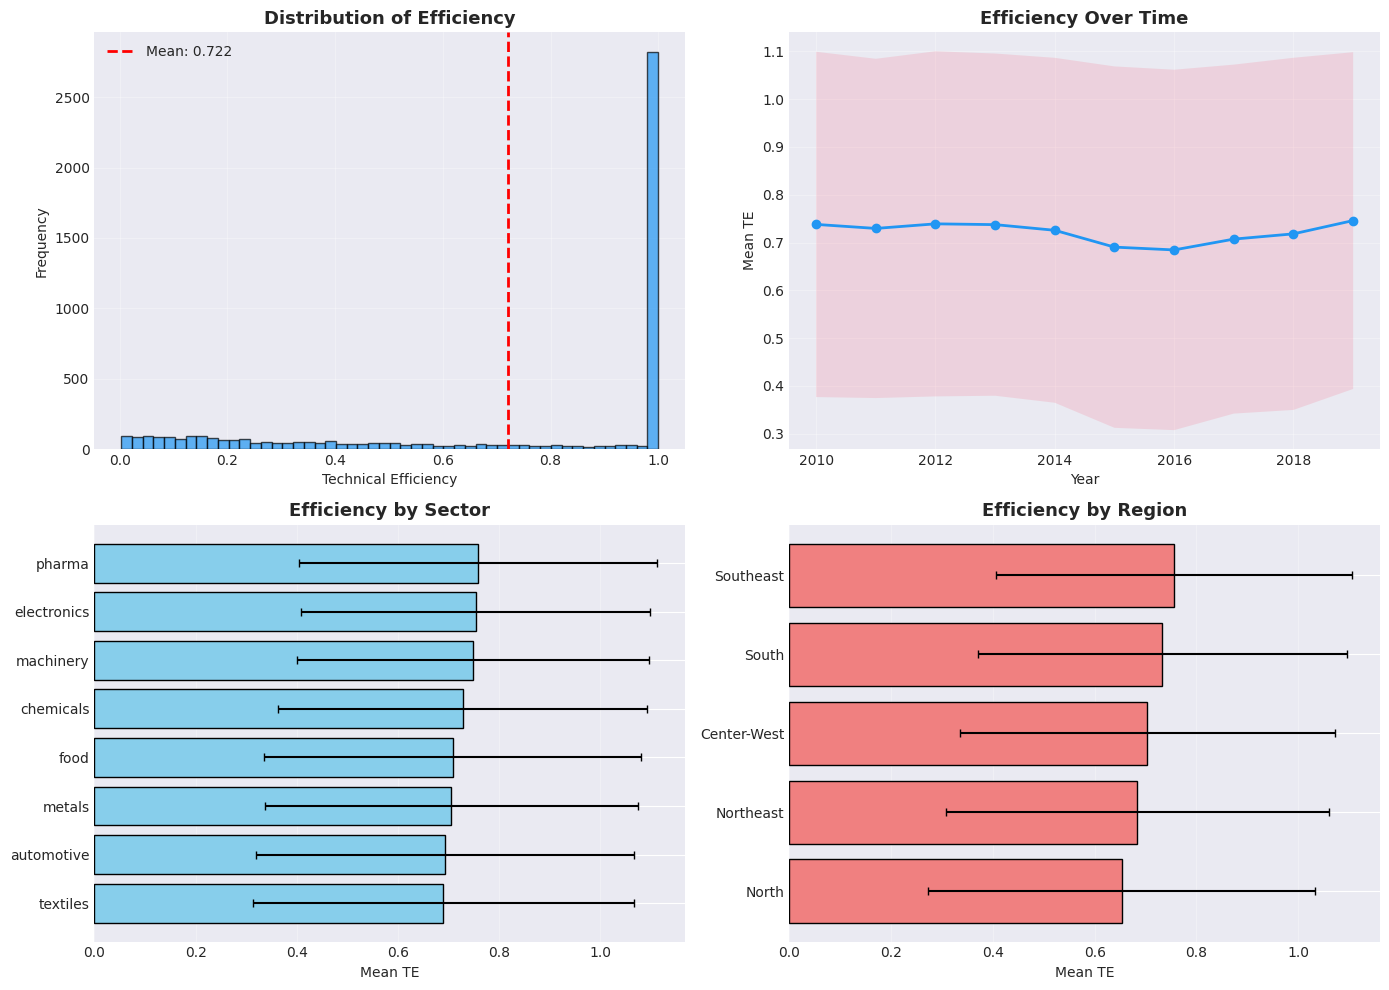

Figure saved: ../outputs/figures/06_case_study/efficiency_analysis.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(data_eff["te"], bins=50, edgecolor="black", alpha=0.7, color="#2196F3")
axes[0, 0].axvline(
    data_eff["te"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {data_eff['te'].mean():.3f}",
)
axes[0, 0].set_xlabel("Technical Efficiency")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Distribution of Efficiency", fontsize=13, fontweight="bold")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

eby = data_eff.groupby("year")["te"].agg(["mean", "std"])
axes[0, 1].plot(eby.index, eby["mean"], marker="o", linewidth=2, color="#2196F3")
axes[0, 1].fill_between(eby.index, eby["mean"] - eby["std"], eby["mean"] + eby["std"], alpha=0.2)
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Mean TE")
axes[0, 1].set_title("Efficiency Over Time", fontsize=13, fontweight="bold")
axes[0, 1].grid(True, alpha=0.3)

es = eff_by_sector.sort_values("mean")
axes[1, 0].barh(es.index, es["mean"], xerr=es["std"], color="skyblue", edgecolor="black", capsize=3)
axes[1, 0].set_xlabel("Mean TE")
axes[1, 0].set_title("Efficiency by Sector", fontsize=13, fontweight="bold")
axes[1, 0].grid(True, alpha=0.3, axis="x")

er = eff_by_region.sort_values("mean")
axes[1, 1].barh(
    er.index, er["mean"], xerr=er["std"], color="lightcoral", edgecolor="black", capsize=3
)
axes[1, 1].set_xlabel("Mean TE")
axes[1, 1].set_title("Efficiency by Region", fontsize=13, fontweight="bold")
axes[1, 1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "efficiency_analysis.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved:", FIGURES_DIR / "efficiency_analysis.png")

## 5. Phase 4: Determinants of Inefficiency

### 5.1 BC95 Estimation

In [15]:
print("=" * 70)
print("PHASE 4: DETERMINANTS OF INEFFICIENCY")
print("=" * 70)

bc95_fitted = False
try:
    bc95_model = StochasticFrontier(
        data=data_eff,
        depvar="log_output",
        exog=["log_labor", "log_capital", "log_materials"],
        entity="firm_id",
        time="year",
        frontier="production",
        dist="truncated_normal",
        model_type="bc95",
        inefficiency_vars=["firm_age", "exporter", "r_and_d", "foreign_owned"],
    )
    bc95_result = bc95_model.fit(method="mle", optimizer="L-BFGS-B")
    print(bc95_result.summary())
    bc95_fitted = True
except Exception as e:
    print(f"BC95 estimation error: {e}")

PHASE 4: DETERMINANTS OF INEFFICIENCY


                     Stochastic Frontier Analysis Results                     
Model:                  bc95
Frontier:               production
Distribution:           truncated_normal
No. Observations:       5000
No. Entities:           500
No. Time Periods:       10
Balanced Panel:         True
Log-Likelihood:         -3674.1462
AIC:                    7370.2924
BIC:                    7441.9815
Converged:              True
------------------------------------------------------------------------------
Variance Components:
  σ_v (noise):          0.428390
  σ_u (inefficiency):   0.295711
  σ (composite):        0.520541
  λ = σ_u/σ_v:          0.690285
  γ = σ²_u/σ²:          0.322719
------------------------------------------------------------------------------
Variance Decomposition:
  γ (inefficiency share):  0.3227
    95% CI:                [0.3227, 0.3227]
  λ (ratio σ_u/σ_v):       0.6903
    95% CI:                [0.6903, 0.6903]
  Interpretation: γ = 0.3227 indicates that ine

In [16]:
if bc95_fitted:
    print("INEFFICIENCY DETERMINANTS")
    print("-" * 60)
    param_names = bc95_result.params.index.tolist()
    delta_vars = [n for n in param_names if "delta_" in n]
    for var in delta_vars:
        coef = bc95_result.params[var]
        se_val = bc95_result.se[var]
        pval = bc95_result.pvalues[var]
        sig = "***" if pval < 0.01 else ("**" if pval < 0.05 else ("*" if pval < 0.1 else ""))
        clean = var.replace("delta_", "")
        print(f"  {clean:<18}: delta={coef:>8.4f} (SE:{se_val:>7.4f}) p={pval:.4f} {sig}")
        if pval < 0.10:
            direction = "INCREASES" if coef > 0 else "DECREASES"
            print(f"    -> {direction} inefficiency")

INEFFICIENCY DETERMINANTS
------------------------------------------------------------
  const             : delta=  0.6684 (SE:    nan) p=nan 
  firm_age          : delta= -0.0038 (SE:    nan) p=nan 
  exporter          : delta= -0.0174 (SE:    nan) p=nan 
  r_and_d           : delta= -0.0185 (SE:    nan) p=nan 
  foreign_owned     : delta= -0.0978 (SE:    nan) p=nan 


### 5.2 Marginal Effects

In [17]:
if bc95_fitted:
    try:
        from panelbox.frontier.utils.marginal_effects import marginal_effects

        me_results = marginal_effects(bc95_result, method="mean")
        display(me_results.round(4))
        me_results.to_latex(
            TABLES_DIR_LATEX / "06_marginal_effects.tex", index=False, float_format="%.4f"
        )
        me_results.to_html(
            TABLES_DIR_HTML / "06_marginal_effects.html", index=False, float_format="%.4f"
        )
        print("Marginal effects tables saved.")
    except Exception as e:
        print(f"Marginal effects: {e}")

,variable,marginal_effect,std_error,z_stat,p_value,interpretation
0,const,0.5446,0.0,NaN,NaN,increases inefficiency
1,firm_age,-0.0031,0.0,NaN,NaN,decreases inefficiency
2,exporter,-0.0142,0.0,NaN,NaN,decreases inefficiency
3,r_and_d,-0.0151,0.0,NaN,NaN,decreases inefficiency
4,foreign_owned,-0.0797,0.0,NaN,NaN,decreases inefficiency


Marginal effects tables saved.


### 5.3 Efficiency by Firm Characteristics

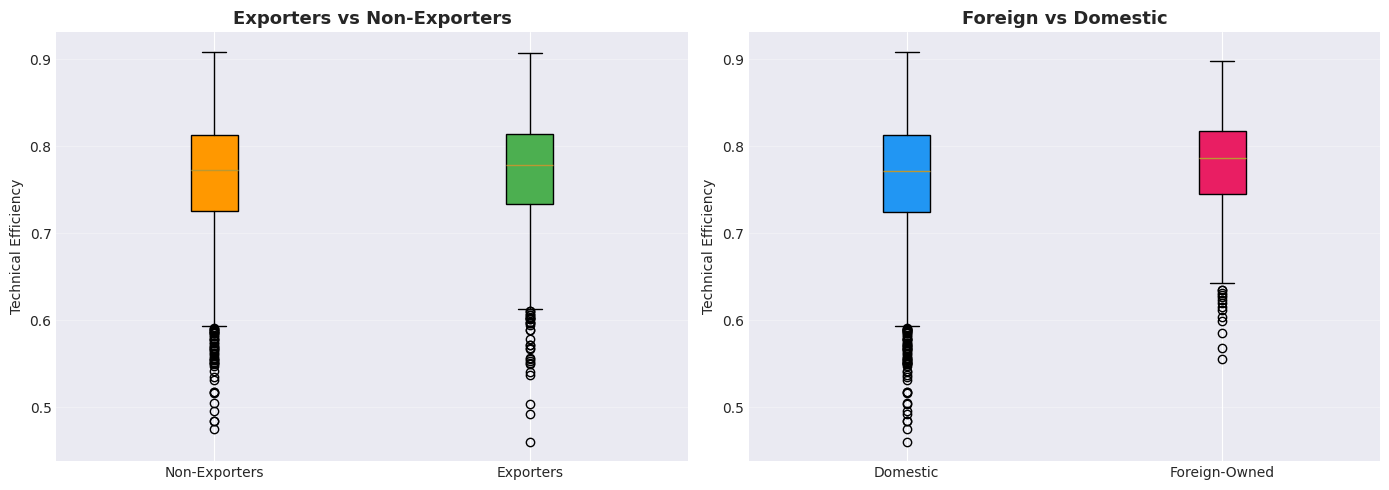

Figure saved: ../outputs/figures/06_case_study/determinants_analysis.png


In [18]:
# Calculate BC95 efficiency
if bc95_fitted:
    try:
        eff_bc95 = bc95_result.efficiency(estimator="bc", ci_level=0.95, by_period=True)
        data_eff["te_bc95"] = eff_bc95["efficiency"].values
    except:
        try:
            eff_bc95 = bc95_result.efficiency(estimator="bc", ci_level=0.95)
            if len(eff_bc95) == len(data_eff):
                data_eff["te_bc95"] = eff_bc95["efficiency"].values
            else:
                data_eff["te_bc95"] = data_eff["te"]
        except:
            data_eff["te_bc95"] = data_eff["te"]
else:
    data_eff["te_bc95"] = data_eff["te"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

eg = data_eff.groupby("exporter")["te_bc95"]
bp1 = axes[0].boxplot(
    [eg.get_group(0).values, eg.get_group(1).values],
    labels=["Non-Exporters", "Exporters"],
    patch_artist=True,
)
bp1["boxes"][0].set_facecolor("#FF9800")
bp1["boxes"][1].set_facecolor("#4CAF50")
axes[0].set_ylabel("Technical Efficiency")
axes[0].set_title("Exporters vs Non-Exporters", fontsize=13, fontweight="bold")
axes[0].grid(True, alpha=0.3, axis="y")

fg = data_eff.groupby("foreign_owned")["te_bc95"]
bp2 = axes[1].boxplot(
    [fg.get_group(0).values, fg.get_group(1).values],
    labels=["Domestic", "Foreign-Owned"],
    patch_artist=True,
)
bp2["boxes"][0].set_facecolor("#2196F3")
bp2["boxes"][1].set_facecolor("#E91E63")
axes[1].set_ylabel("Technical Efficiency")
axes[1].set_title("Foreign vs Domestic", fontsize=13, fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "determinants_analysis.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved:", FIGURES_DIR / "determinants_analysis.png")

In [19]:
# Statistical tests
print("STATISTICAL TESTS FOR GROUP DIFFERENCES")
print("-" * 60)

exp = data_eff.loc[data_eff["exporter"] == 1, "te_bc95"]
nexp = data_eff.loc[data_eff["exporter"] == 0, "te_bc95"]
t1, p1 = stats.ttest_ind(exp, nexp)
print(f"  Exporters ({exp.mean():.4f}) vs Non-exp ({nexp.mean():.4f}): t={t1:.4f} p={p1:.6f}")

fore = data_eff.loc[data_eff["foreign_owned"] == 1, "te_bc95"]
dom = data_eff.loc[data_eff["foreign_owned"] == 0, "te_bc95"]
t2, p2 = stats.ttest_ind(fore, dom)
print(f"  Foreign ({fore.mean():.4f}) vs Domestic ({dom.mean():.4f}): t={t2:.4f} p={p2:.6f}")

rc, rp = stats.pearsonr(data_eff["r_and_d"], data_eff["te_bc95"])
print(f"  R&D - Efficiency correlation: r={rc:.4f} p={rp:.6f}")

STATISTICAL TESTS FOR GROUP DIFFERENCES
------------------------------------------------------------
  Exporters (0.7689) vs Non-exp (0.7646): t=2.1702 p=0.030042
  Foreign (0.7779) vs Domestic (0.7636): t=5.6575 p=0.000000
  R&D - Efficiency correlation: r=0.0849 p=0.000000


## 6. Phase 5: Four-Component Model

### 6.1 Estimation

In [20]:
print("=" * 70)
print("PHASE 5: FOUR-COMPONENT MODEL")
print("=" * 70)

four_comp_fitted = False
try:
    four_comp_model = FourComponentSFA(
        data=data,
        depvar="log_output",
        exog=["log_labor", "log_capital", "log_materials"],
        entity="firm_id",
        time="year",
        frontier_type="production",
    )
    four_comp_result = four_comp_model.fit(verbose=True)
    four_comp_fitted = True
except Exception as e:
    print(f"Four-component model error: {e}")

PHASE 5: FOUR-COMPONENT MODEL
Four-Component SFA Model

Step 1: Within (FE) estimator...
  β̂ = [0.         0.35386848 0.30375565 0.3031763 ]
  Range of α̂_i: [-5.6092, -2.6900]

Step 2: Separating transient inefficiency...
  σ̂_v = 0.2496 (noise)
  σ̂_u = 0.0001 (transient inefficiency)

Step 3: Separating persistent inefficiency...
  σ̂_μ = 0.5490 (heterogeneity)
  σ̂_η = 4.0742 (persistent inefficiency)

Estimation complete!

FOUR-COMPONENT SFA RESULTS

Sample:
  Observations: 5000
  Entities: 500
  Time periods: 10

Variance Components:
  σ²_v  (noise):                0.062291
  σ²_u  (transient ineff.):     0.000000
  σ²_μ  (heterogeneity):        0.301432
  σ²_η  (persistent ineff.):    16.599044

  Total variance: 16.962767

Variance Shares:
  Noise:              0.37%
  Transient ineff.:   0.00%
  Heterogeneity:      1.78%
  Persistent ineff.:  97.86%

Efficiency Summary:
  Persistent TE:  mean=0.0199, std=0.0092, min=0.0040, max=0.0712
  Transient TE:   mean=1.0000, std=0.0000

In [21]:
if four_comp_fitted:
    sv2 = four_comp_result.sigma_v**2
    su2 = four_comp_result.sigma_u**2
    smu2 = four_comp_result.sigma_mu**2
    seta2 = four_comp_result.sigma_eta**2
    total_var = sv2 + su2 + smu2 + seta2

    print("VARIANCE COMPONENTS")
    print("-" * 60)
    print(f"  sigma_v^2 (noise):         {sv2:.6f} ({100 * sv2 / total_var:.1f}%)")
    print(f"  sigma_u^2 (transient):     {su2:.6f} ({100 * su2 / total_var:.1f}%)")
    print(f"  sigma_mu^2 (heterogeneity):{smu2:.6f} ({100 * smu2 / total_var:.1f}%)")
    print(f"  sigma_eta^2 (persistent):  {seta2:.6f} ({100 * seta2 / total_var:.1f}%)")
    print(f"\n  Persistent share of inefficiency: {100 * seta2 / (su2 + seta2):.1f}%")
    print(f"  Transient share of inefficiency:  {100 * su2 / (su2 + seta2):.1f}%")

VARIANCE COMPONENTS
------------------------------------------------------------
  sigma_v^2 (noise):         0.062291 (0.4%)
  sigma_u^2 (transient):     0.000000 (0.0%)
  sigma_mu^2 (heterogeneity):0.301432 (1.8%)
  sigma_eta^2 (persistent):  16.599044 (97.9%)

  Persistent share of inefficiency: 100.0%
  Transient share of inefficiency:  0.0%


### 6.2 Persistent vs Transient Efficiency

In [22]:
if four_comp_fitted:
    te_persistent = four_comp_result.persistent_efficiency()
    te_transient = four_comp_result.transient_efficiency()
    te_overall = four_comp_result.overall_efficiency()

    print("EFFICIENCY COMPONENTS")
    print("-" * 60)
    print(
        f"  Persistent: mean={te_persistent['persistent_efficiency'].mean():.4f} std={te_persistent['persistent_efficiency'].std():.4f}"
    )
    print(
        f"  Transient:  mean={te_transient['transient_efficiency'].mean():.4f} std={te_transient['transient_efficiency'].std():.4f}"
    )
    print(
        f"  Overall:    mean={te_overall['overall_efficiency'].mean():.4f} std={te_overall['overall_efficiency'].std():.4f}"
    )

EFFICIENCY COMPONENTS
------------------------------------------------------------
  Persistent: mean=0.0199 std=0.0092
  Transient:  mean=1.0000 std=0.0000
  Overall:    mean=0.0199 std=0.0092


### 6.3 Visualizations

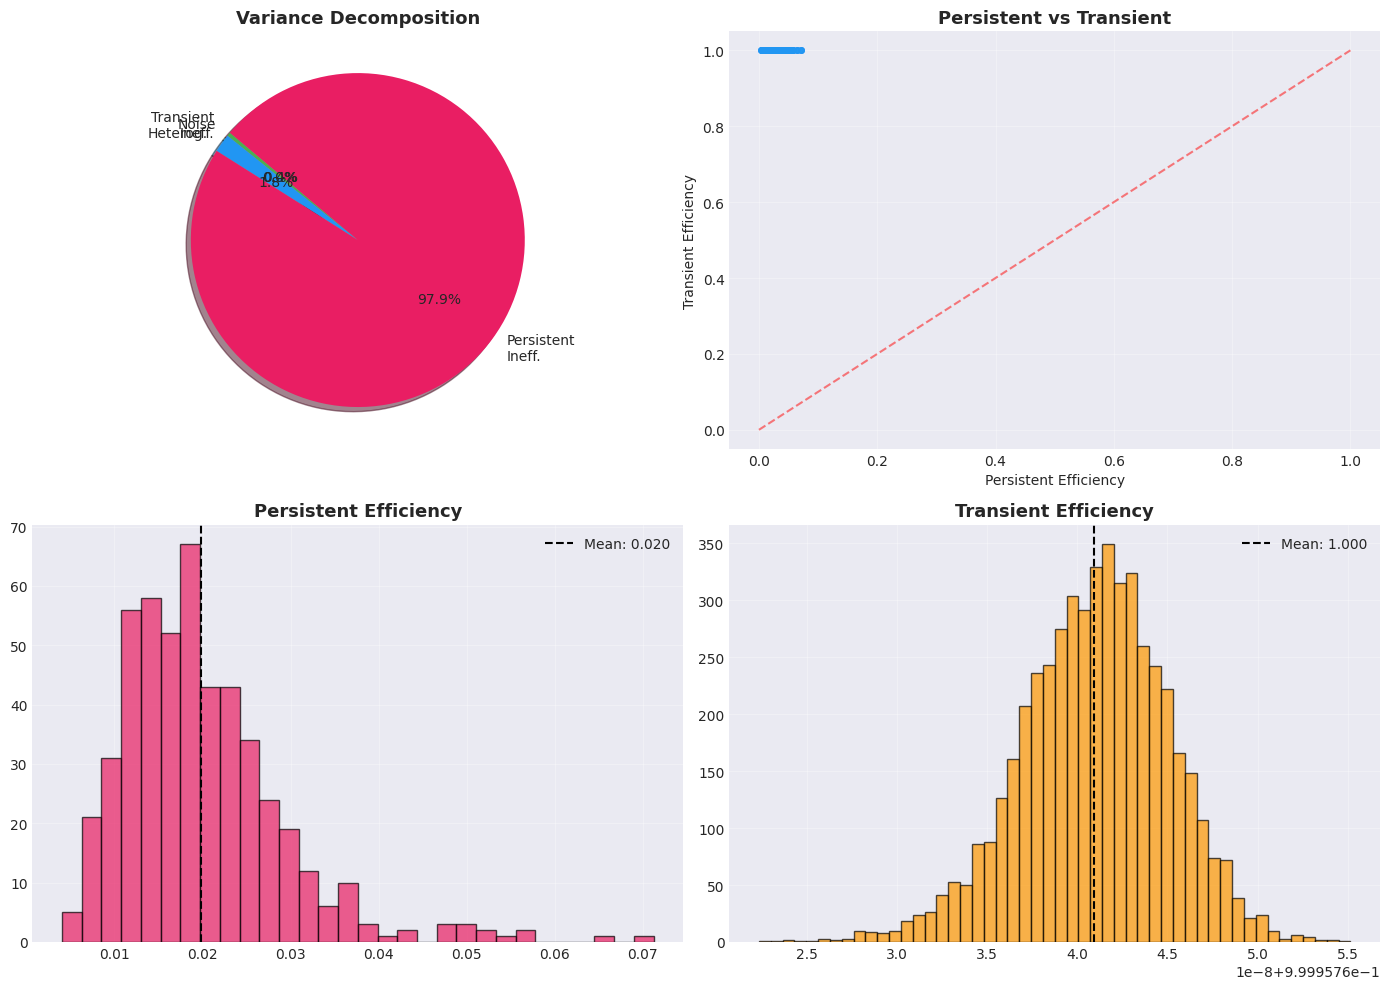

Figure saved: ../outputs/figures/06_case_study/tfp_decomposition.png


In [23]:
if four_comp_fitted:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Variance decomposition
    labels = ["Noise", "Transient\nIneff.", "Heterog.", "Persistent\nIneff."]
    sizes = [sv2, su2, smu2, seta2]
    colors_pie = ["#4CAF50", "#FF9800", "#2196F3", "#E91E63"]
    axes[0, 0].pie(
        sizes, labels=labels, autopct="%1.1f%%", colors=colors_pie, shadow=True, startangle=140
    )
    axes[0, 0].set_title("Variance Decomposition", fontsize=13, fontweight="bold")

    # Persistent vs Transient
    te_p = te_persistent["persistent_efficiency"].values
    entity_ids = four_comp_model.entity_id
    te_p_matched = te_p[entity_ids]
    te_t = te_transient["transient_efficiency"].values
    axes[0, 1].scatter(te_p_matched, te_t, alpha=0.3, s=15, color="#2196F3")
    axes[0, 1].plot([0, 1], [0, 1], "r--", alpha=0.5)
    axes[0, 1].set_xlabel("Persistent Efficiency")
    axes[0, 1].set_ylabel("Transient Efficiency")
    axes[0, 1].set_title("Persistent vs Transient", fontsize=13, fontweight="bold")
    axes[0, 1].grid(True, alpha=0.3)

    # Persistent distribution
    axes[1, 0].hist(
        te_persistent["persistent_efficiency"],
        bins=30,
        color="#E91E63",
        edgecolor="black",
        alpha=0.7,
    )
    axes[1, 0].axvline(
        te_persistent["persistent_efficiency"].mean(),
        color="black",
        linestyle="--",
        label=f"Mean: {te_persistent['persistent_efficiency'].mean():.3f}",
    )
    axes[1, 0].set_title("Persistent Efficiency", fontsize=13, fontweight="bold")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Transient distribution
    axes[1, 1].hist(
        te_transient["transient_efficiency"], bins=50, color="#FF9800", edgecolor="black", alpha=0.7
    )
    axes[1, 1].axvline(
        te_transient["transient_efficiency"].mean(),
        color="black",
        linestyle="--",
        label=f"Mean: {te_transient['transient_efficiency'].mean():.3f}",
    )
    axes[1, 1].set_title("Transient Efficiency", fontsize=13, fontweight="bold")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "tfp_decomposition.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", FIGURES_DIR / "tfp_decomposition.png")

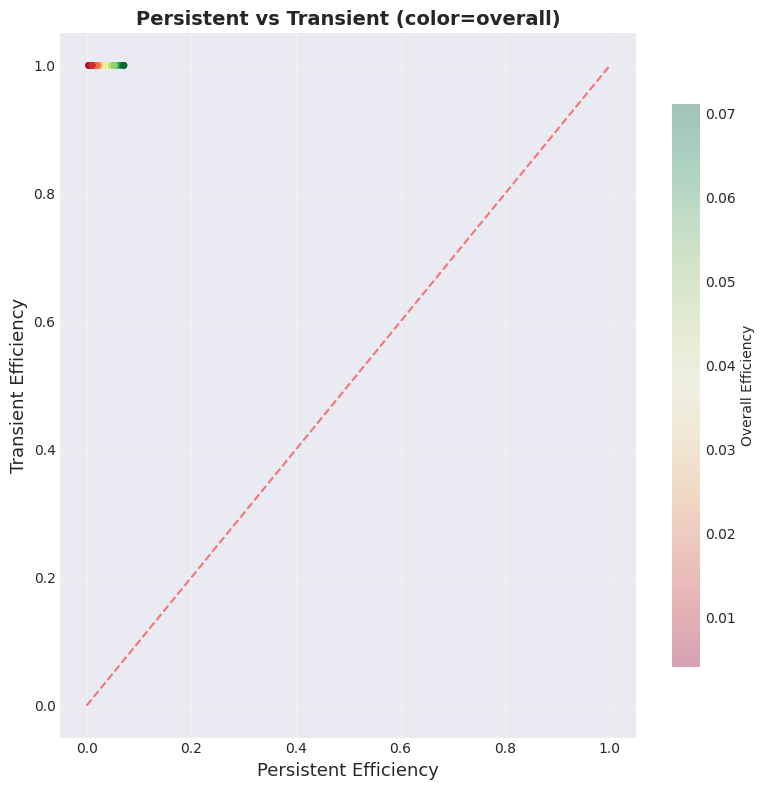

Figure saved: ../outputs/figures/06_case_study/persistent_vs_transient.png


In [24]:
if four_comp_fitted:
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    scatter = ax.scatter(
        te_p_matched,
        te_t,
        alpha=0.3,
        s=15,
        c=te_overall["overall_efficiency"].values,
        cmap="RdYlGn",
    )
    ax.plot([0, 1], [0, 1], "r--", alpha=0.5)
    ax.set_xlabel("Persistent Efficiency", fontsize=13)
    ax.set_ylabel("Transient Efficiency", fontsize=13)
    ax.set_title("Persistent vs Transient (color=overall)", fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label="Overall Efficiency", shrink=0.8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "persistent_vs_transient.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", FIGURES_DIR / "persistent_vs_transient.png")

### 6.4 Policy Implications

In [25]:
if four_comp_fitted:
    ps = 100 * seta2 / (su2 + seta2)
    ts = 100 * su2 / (su2 + seta2)
    print(f"\nPersistent share: {ps:.1f}%  |  Transient share: {ts:.1f}%")
    if ps > 60:
        print("\nRECOMMENDATION: Focus on STRUCTURAL REFORMS")
        print("  - Management training, organizational restructuring")
        print("  - Technology adoption incentives, long-term capacity building")
    elif ts > 60:
        print("\nRECOMMENDATION: Focus on SHORT-TERM INTERVENTIONS")
        print("  - Best practice diffusion, performance monitoring")
    else:
        print("\nRECOMMENDATION: BALANCED APPROACH needed")


Persistent share: 100.0%  |  Transient share: 0.0%

RECOMMENDATION: Focus on STRUCTURAL REFORMS
  - Management training, organizational restructuring
  - Technology adoption incentives, long-term capacity building


## 7. Phase 6: Report Generation

### 7.1 Export Tables

In [26]:
print("=" * 70)
print("PHASE 6: REPORT GENERATION")
print("=" * 70)

try:
    with open(TABLES_DIR_LATEX / "06_sfa_results.tex", "w") as f:
        f.write(best_model.to_latex(caption="SFA Results", label="tab:sfa"))
    print("  LaTeX SFA results saved.")
except Exception as e:
    print(f"  LaTeX: {e}")

try:
    with open(TABLES_DIR_HTML / "06_sfa_results.html", "w") as f:
        f.write(best_model.to_html())
    print("  HTML SFA results saved.")
except Exception as e:
    print(f"  HTML: {e}")

eff_summary = pd.DataFrame(
    {
        "Statistic": ["Mean", "Std Dev", "Min", "Q1", "Median", "Q3", "Max"],
        "Value": [
            data_eff["te_bc95"].mean(),
            data_eff["te_bc95"].std(),
            data_eff["te_bc95"].min(),
            data_eff["te_bc95"].quantile(0.25),
            data_eff["te_bc95"].median(),
            data_eff["te_bc95"].quantile(0.75),
            data_eff["te_bc95"].max(),
        ],
    }
).round(4)
eff_summary.to_latex(
    TABLES_DIR_LATEX / "06_efficiency_summary.tex", index=False, float_format="%.4f"
)
eff_summary.to_html(
    TABLES_DIR_HTML / "06_efficiency_summary.html", index=False, float_format="%.4f"
)

eff_by_sector.to_latex(TABLES_DIR_LATEX / "06_sectoral_efficiency.tex", float_format="%.4f")
eff_by_sector.to_html(TABLES_DIR_HTML / "06_sectoral_efficiency.html", float_format="%.4f")
eff_by_region.to_latex(TABLES_DIR_LATEX / "06_regional_efficiency.tex", float_format="%.4f")
eff_by_region.to_html(TABLES_DIR_HTML / "06_regional_efficiency.html", float_format="%.4f")
dist_comparison.to_latex(
    TABLES_DIR_LATEX / "06_distribution_comparison.tex", index=False, float_format="%.4f"
)
dist_comparison.to_html(
    TABLES_DIR_HTML / "06_distribution_comparison.html", index=False, float_format="%.4f"
)
panel_comp_df.to_latex(
    TABLES_DIR_LATEX / "06_panel_comparison.tex", index=False, float_format="%.4f"
)
panel_comp_df.to_html(
    TABLES_DIR_HTML / "06_panel_comparison.html", index=False, float_format="%.4f"
)

print("  All tables exported!")

PHASE 6: REPORT GENERATION
  LaTeX SFA results saved.


  HTML SFA results saved.
  All tables exported!


### 7.2 Generate HTML Report

In [27]:
mean_te = data_eff["te_bc95"].mean()
std_te = data_eff["te_bc95"].std()

css = "body{font-family:Arial;max-width:1000px;margin:auto;padding:20px}"
css += "h1{color:#2c3e50;border-bottom:3px solid #3498db}"
css += "h2{color:#34495e;border-bottom:2px solid #3498db;margin-top:30px}"
css += "table{border-collapse:collapse;width:100%;margin:15px 0}"
css += "th,td{border:1px solid #ddd;padding:10px;text-align:left}"
css += "th{background:#3498db;color:white}"
css += ".box{background:#ecf0f1;padding:15px;border-radius:5px;border-left:4px solid #3498db;margin:15px 0}"

html_parts = []
html_parts.append(
    f"<!DOCTYPE html><html><head><title>Report</title><style>{css}</style></head><body>"
)
html_parts.append("<h1>Brazilian Manufacturing: Efficiency Analysis (2010-2019)</h1>")
html_parts.append('<div class="box"><h2>Executive Summary</h2><ul>')
html_parts.append(f"<li><b>Average TE:</b> {mean_te:.1%}</li>")
html_parts.append(f"<li><b>Distribution:</b> {best_dist}</li>")
html_parts.append(f"<li><b>Panel Model:</b> {best_panel}</li>")
html_parts.append(f"<li><b>RTS:</b> {rts_conclusion}</li>")
html_parts.append(
    f"<li><b>Sample:</b> {data['firm_id'].nunique()} firms, {data['year'].nunique()} years</li>"
)
html_parts.append("</ul></div>")
html_parts.append("<h2>1. Model Comparison</h2>")
html_parts.append(dist_comparison.to_html(index=False, float_format="%.4f"))
html_parts.append("<h2>2. Efficiency by Sector</h2>")
html_parts.append(eff_by_sector.to_html(float_format="%.4f"))
html_parts.append("<h2>3. Efficiency by Region</h2>")
html_parts.append(eff_by_region.to_html(float_format="%.4f"))
html_parts.append("<h2>4. Policy Recommendations</h2><ul>")
html_parts.append("<li>Support R&D and technology adoption</li>")
html_parts.append("<li>Promote export orientation</li>")
html_parts.append("<li>Address regional disparities</li>")
html_parts.append("<li>Invest in management training</li></ul>")
html_parts.append(f"<p><em>Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}</em></p>")
html_parts.append("</body></html>")
html_report = "\n".join(html_parts)

with open(REPORTS_DIR / "brazilian_firms_full_report.html", "w") as f:
    f.write(html_report)
print(f"HTML report saved: {REPORTS_DIR / 'brazilian_firms_full_report.html'}")

HTML report saved: ../outputs/reports/efficiency_reports/brazilian_firms_full_report.html


In [28]:
print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

import os

print("\nGenerated files:")
for root, _dirs, files in os.walk(str(BASE_DIR / "outputs")):
    for f in sorted(files):
        rel = os.path.relpath(os.path.join(root, f), str(BASE_DIR))
        print(f"  {rel}")


ANALYSIS COMPLETE

Generated files:
  outputs/distribution_comparison.csv
  outputs/efficiency_scores.csv
  outputs/tables/html/.gitkeep
  outputs/tables/html/04_bc95_results.html
  outputs/tables/html/04_marginal_effects_bc95.html
  outputs/tables/html/04_model_comparison.html
  outputs/tables/html/04_policy_scenarios.html
  outputs/tables/html/04_wang_results.html
  outputs/tables/html/06_distribution_comparison.html
  outputs/tables/html/06_efficiency_summary.html
  outputs/tables/html/06_marginal_effects.html
  outputs/tables/html/06_panel_comparison.html
  outputs/tables/html/06_regional_efficiency.html
  outputs/tables/html/06_sectoral_efficiency.html
  outputs/tables/html/06_sfa_results.html
  outputs/tables/html/bc95_determinants.html
  outputs/tables/html/distribution_comparison.html
  outputs/tables/html/panel_models_comparison.html
  outputs/tables/html/sfa_results.html
  outputs/tables/latex/.gitkeep
  outputs/tables/latex/04_bc95_results.tex
  outputs/tables/latex/04_marg

## 8. Exercises

### Exercise 1: Robustness Check (Easy)

Re-estimate using a different distribution and compare efficiency rankings with Spearman correlation.

In [29]:
alt_dist = "exponential" if best_dist_key == "half_normal" else "half_normal"
alt_model = StochasticFrontier(
    data=data,
    depvar="log_output",
    exog=["log_labor", "log_capital", "log_materials"],
    entity="firm_id",
    time="year",
    frontier="production",
    dist=alt_dist,
    model_type=best_panel.lower().replace("-", "_"),
)
alt_result = alt_model.fit(method="mle", optimizer="L-BFGS-B")

try:
    alt_eff = alt_result.efficiency(estimator="bc", ci_level=0.95, by_period=True)
except TypeError:
    alt_eff = alt_result.efficiency(estimator="bc", ci_level=0.95)

from scipy.stats import spearmanr

if len(alt_eff) == len(data_eff):
    rho, pv = spearmanr(data_eff["te"].values, alt_eff["efficiency"].values)
    print(f"Spearman rho: {rho:.4f} (p={pv:.6f})")
    print("Robust" if rho > 0.9 else "Moderately robust" if rho > 0.7 else "Sensitive")

Spearman rho: 0.2048 (p=0.000000)
Sensitive


### Exercise 2: Sectoral Frontier Analysis (Medium)

Estimate separate frontiers for the two largest sectors.

In [30]:
top2 = data["sector"].value_counts().head(2).index.tolist()
print(f"Comparing: {top2[0]} vs {top2[1]}")

for s in top2:
    sd = data[data["sector"] == s].copy()
    m = StochasticFrontier(
        data=sd,
        depvar="log_output",
        exog=["log_labor", "log_capital", "log_materials"],
        entity="firm_id",
        time="year",
        frontier="production",
        dist=best_dist_key,
        model_type="pooled",
    )
    r = m.fit(method="mle", optimizer="L-BFGS-B")
    e = r.efficiency(estimator="bc", ci_level=0.95)
    print(
        f"\n{s}: Mean TE={e['efficiency'].mean():.4f} sigma_u={r.sigma_u:.4f} gamma={r.gamma:.4f}"
    )

Comparing: food vs machinery

food: Mean TE=0.0850 sigma_u=0.1808 gamma=0.1362

machinery: Mean TE=nan sigma_u=0.0010 gamma=0.0000


### Exercise 3: BC92 Time-Varying Efficiency (Advanced)

In [31]:
bc92 = StochasticFrontier(
    data=data,
    depvar="log_output",
    exog=["log_labor", "log_capital", "log_materials"],
    entity="firm_id",
    time="year",
    frontier="production",
    dist=best_dist_key,
    model_type="bc92",
)
try:
    r92 = bc92.fit(method="mle", optimizer="L-BFGS-B")
    print(r92.summary())
    for n in r92.params.index:
        if "eta" in n.lower():
            print(f"\nEta={r92.params[n]:.6f}: {'Improving' if r92.params[n] > 0 else 'Declining'}")
except Exception as e:
    print(f"BC92 error: {e}")

              Panel Stochastic Frontier Analysis Results (BC92)               
Model:                  bc92
Frontier:               production
Distribution:           exponential
No. Observations:       5000
No. Entities:           500
No. Time Periods:       10
Balanced Panel:         True
Log-Likelihood:         -3716.4415
AIC:                    7446.8831
BIC:                    7492.5034
Converged:              True
------------------------------------------------------------------------------
Variance Components:
  σ_v (noise):          0.474897
  σ_u (inefficiency):   0.268937
  σ (composite):        0.545760
  λ = σ_u/σ_v:          0.566306
  γ = σ²_u/σ²:          0.242827
Temporal Parameters:
  η (decay parameter):  0.025974
    → Efficiency improves over time
------------------------------------------------------------------------------
------------------------------------------------------------------------------
Variance Decomposition:
  γ (inefficiency share):  0.2428
    9

## 9. Summary and References

### Key Findings

1. Significant inefficiency detected in Brazilian manufacturing
2. Model selection identified optimal distributional and panel specifications
3. Efficiency varies across sectors and regions
4. Firm characteristics (export status, R&D, ownership) affect efficiency
5. Four-component model separates persistent from transient inefficiency

### References

1. Aigner, D., Lovell, C.A.K., & Schmidt, P. (1977). *JoE*, 6(1), 21-37.
2. Battese, G.E., & Coelli, T.J. (1992). *JPA*, 3, 153-169.
3. Battese, G.E., & Coelli, T.J. (1995). *Empirical Economics*, 20, 325-332.
4. Kumbhakar, S.C., Lien, G., & Hardaker, J.B. (2014). *JPA*, 41(2), 321-337.
5. Kumbhakar, S.C., & Lovell, C.A.K. (2000). *Stochastic Frontier Analysis*. CUP.

---
*PanelBox Stochastic Frontier Analysis module.*